## Cost of living data analysis
This project will focus on the analysis of various categories contributing to the general cost of living, with a focus on staple food products, housing prices, inflation, and wages. We are aiming to answer the following questions throughout the course of our analysis:


1. How has the cost of paying for groceries for a family of 4 changed over the years (3.13 as the national average of people in household)?

2. How has the price of groceries increased in comparison to inflation over the years?

3. How has the price of groceries increased in comparison to wages over the years?

4. Is there any correlation between any dips in purchasing groceries and the rise in prices in other areas such as the housing market?

5. How has the price of staple foods such as milk, eggs, bread increased over the years?

6. How has the price of unhealthy foods increased over the years in comparison to the increase in the price of healthy foods over the years?


## Basic metrics
We want to start with our historical food data, which include percent change in price for a wide range of food categories, and we begin by focusing on the categories that relate to our research questions

Index(['Consumer Price Index item', 'Year', 'Percent change'], dtype='object')
(np.int64(1974), np.int64(2024))
['All food' 'Food away from home' 'Food at home'
 'Meats, poultry, and fish' 'Meats' 'Beef and veal' 'Pork' 'Other meats'
 'Poultry' 'Fish and seafood' 'Eggs' 'Dairy products' 'Fats and oils'
 'Fruits and vegetables' 'Fresh fruits and vegetables' 'Fresh fruits'
 'Fresh vegetables' 'Processed fruits and vegetables' 'Sugar and sweets'
 'Cereals and bakery products' 'Nonalcoholic beverages' 'Other foods']


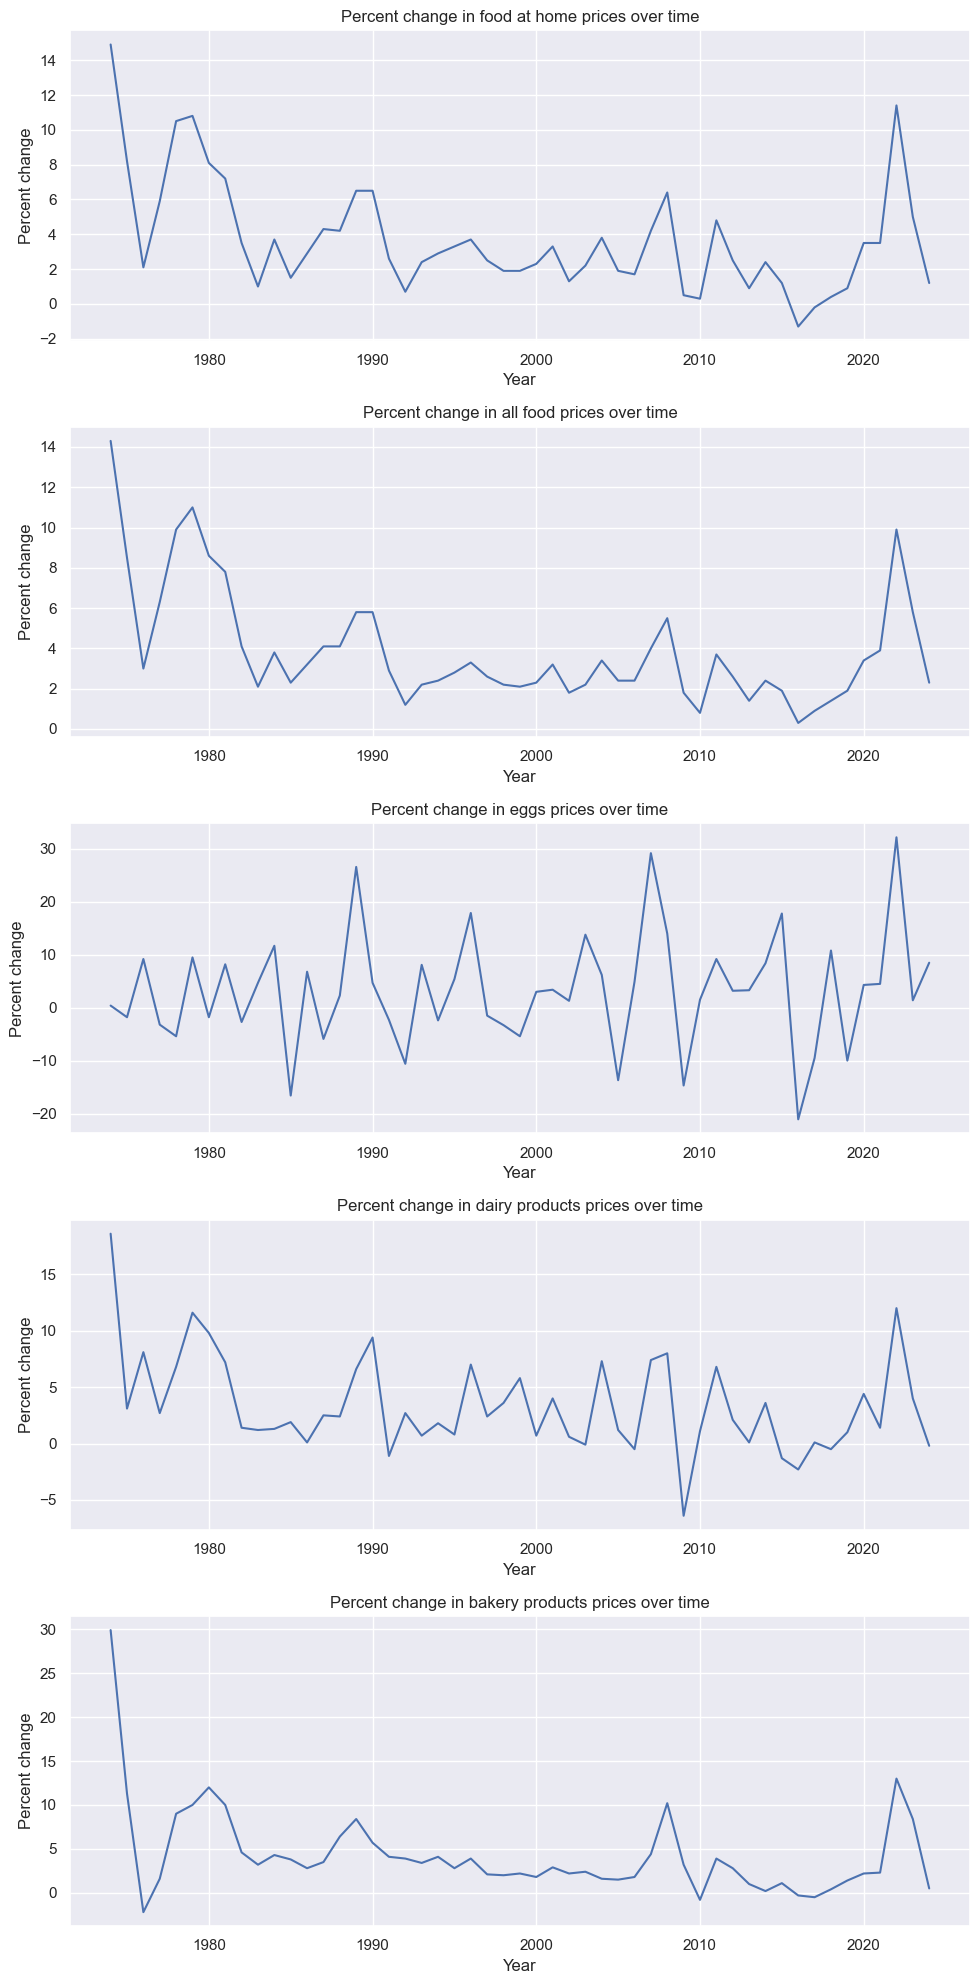

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# First step is to clean our data

df = pd.read_csv("data/historicalcpi.csv")

# print(df.head())
print(df.columns)

# print(df.isna().sum())
# print(df.duplicated().sum())

# after closer inspection, the missing values are percent changes in proccessed fruits and vegetables,
# assumingly from missing data, as filling those in would skew predictions, we will make a new dataset with those values omitted

clean_df = df.dropna()
# print(clean_df.isna().sum())
# print(clean_df.shape)

time_frame = ((clean_df["Year"].min()), (clean_df["Year"].max()))
print(time_frame)

print(clean_df["Consumer Price Index item"].unique())

food_at_home = clean_df[clean_df["Consumer Price Index item"] == "Food at home"]
all_food = clean_df[clean_df["Consumer Price Index item"] == "All food"]
eggs = clean_df[clean_df["Consumer Price Index item"] == "Eggs"]
diary = clean_df[clean_df["Consumer Price Index item"] == "Dairy products"]
bakery = clean_df[
    clean_df["Consumer Price Index item"] == "Cereals and bakery products"
]


sns.set_theme()

fig, axs = plt.subplots(5, figsize=(10, 20))
sns.lineplot(data=food_at_home, x="Year", y="Percent change", ax=axs[0]).set(
    title="Percent change in food at home prices over time"
)
sns.lineplot(data=all_food, x="Year", y="Percent change", ax=axs[1]).set(
    title="Percent change in all food prices over time"
)
sns.lineplot(data=eggs, x="Year", y="Percent change", ax=axs[2]).set(
    title="Percent change in eggs prices over time"
)
sns.lineplot(data=diary, x="Year", y="Percent change", ax=axs[3]).set(
    title="Percent change in dairy products prices over time"
)
sns.lineplot(data=bakery, x="Year", y="Percent change", ax=axs[4]).set(
    title="Percent change in bakery products prices over time"
)

plt.tight_layout()
plt.show()

## Basic metric analysis
After seeing these basic plots, we can draw conclusions on which food categories were more stable than others, and bring context through historical periods of America's economy to explain the graphs.

We can look at Cereal and Bakery products, which seem to be one of the more stable food categories, with relatively low percent changes in price over the years. Though with foods like eggs, we see much more volatility over the years, which makes things more difficult to predict regarding eggs

We can also layer these graphs on one another and see what time periods affected all the food categories together:

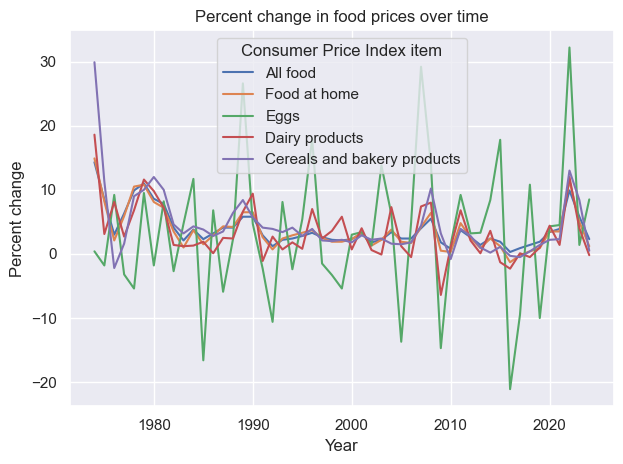

In [ ]:
basic_metrics = clean_df[
    clean_df["Consumer Price Index item"].isin(
        [
            "Food at home",
            "All food",
            "Eggs",
            "Dairy products",
            "Cereals and bakery products",
        ]
    )
]
sns.lineplot(
    data=basic_metrics, x="Year", y="Percent change", hue="Consumer Price Index item"
).set(title="Percent change in food prices over time")

## Historical analysis
After layering the graphs on top of one another, we can highlight some key points in history to explain some of the more drastic price changes. We see a drastic price change around the 1970-1980 range, which we can explain through what's commonly known as 'The Great Inflation,' a period in the Nixon presidency that saw huge rates of inflation, causing the drastic price changes we see reflected in our data. Another key historical period in which food prices changed drastically was 2020 through 2024, when Covid-19 ravaged the world and led to drastic price changes in American groceries and households in general.
    

## How has the cost of groceries for a family of 4 changed over time?

In this section we examine how the cost of groceries for a standard family of 4 has changed throughout the years. In order to analyze this, we load and clean up a few different datasets from the U.S. Department of Agriculture. These datasets span from around 1985 up to 2026, though after cleaning our period shrunk to 1994-2021. In order for this data to be usable, we had to go through a little cleaning and reorganizing in order to combine them into a smooth time series for analysis, the details of which will be commented throughout our code snippet below. 



(327, 9)
 From 1994 to 2021, the average moderate 4-family foodplan had a percent change of: 85.63402162928556
The average annual change in price is: 229.39191919191924
The average annual percent change is: 2.3357600130576066


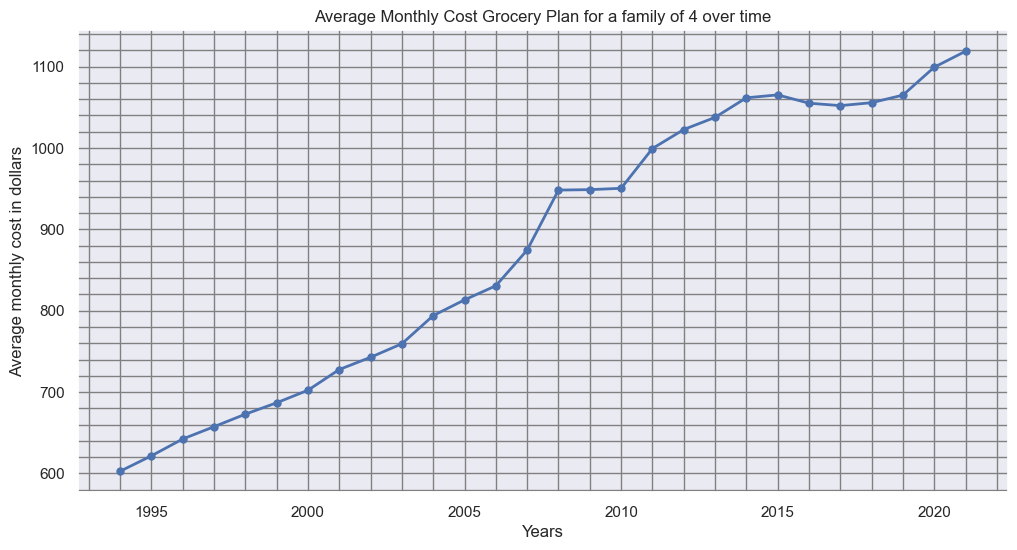

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# First we read the 3 food plan sets using pandas
pre_2003_foodplan = pd.read_excel(
    "data/usda-moderatecostplan-pre-march2003.xlsx", sheet_name="Moderate-Cost 94-03"
)
foodplan_03_07 = pd.read_excel(
    "data/usda-moderatecostplan-march2003-aug2007.xlsx",
    sheet_name="Moderate-Cost 03-07",
)
foodplan_07_present = pd.read_excel(
    "data/cnpp-moderatecostplan-sept2007-present.xlsx",
    sheet_name="Moderate-Cost 07-Pres",
)

# We then applied a few filters ensuring we were only grabbing monthly data pertaining to the U.S
norm1 = pre_2003_foodplan[
    (pre_2003_foodplan["geographic_area"] == "Mainland U.S.")
    & (pre_2003_foodplan["frequency"] == "Monthly")
].copy()
norm2 = foodplan_03_07[
    (foodplan_03_07["geographic_area"] == "Mainland U.S.")
    & (foodplan_03_07["frequency"] == "Monthly")
].copy()
norm3 = foodplan_07_present[
    (foodplan_07_present["location"] == "Mainland U.S.")
    & (foodplan_07_present["frequency"] == "Monthly")
].copy()

# We then normalized some column names and converted the year and cost columns to numbers for analysis
norm3 = norm3.rename(columns={"location": "geographic_area"})
norm1["year"] = pd.to_numeric(norm1["year"], errors="coerce")
norm2["year"] = pd.to_numeric(norm2["year"], errors="coerce")
norm3["year"] = pd.to_numeric(norm3["year"], errors="coerce")

norm1["cost"] = pd.to_numeric(norm1["cost"], errors="coerce")
norm2["cost"] = pd.to_numeric(norm2["cost"], errors="coerce")
norm3["cost"] = pd.to_numeric(norm3["cost"], errors="coerce")

# Then we examined the unique values from fam_indv, group, and age columns to decide how we wanted to build our data around a 4 family profile
"""print(norm1['fam_indv'].unique())
print(norm1['group'].unique())
print(norm1['age'].unique())

print(norm2['fam_indv'].unique())
print(norm2['group'].unique())
print(norm2['age'].unique())

print(norm3['fam_indv'].unique())
print(norm3['group'].unique())
print(norm3['age'].unique())"""

# We ended up deciding on using the premade family category, including children from a broad age range
family1 = norm1[
    (norm1["fam_indv"] == "Family")
    & (norm1["group"] == "Couple and children")
    & (norm1["age"] == "20-50 years and children 6-8 and 9-11 years")
].copy()
family2 = norm2[
    (norm2["fam_indv"] == "Family")
    & (norm2["group"] == "Couple and children")
    & (norm2["age"] == "20-50 years and children 6-8 and 9-11 years")
].copy()
family3 = norm3[
    (norm3["fam_indv"] == "Family")
    & (norm3["group"] == "Couple and children")
    & (norm3["age"] == "19-50 years and children 6-8 and 9-11 years")
].copy()

# After all the cleaning was done, we filtered the columns we needed for analysis once again
family1 = family1[
    [
        "geographic_area",
        "fam_indv",
        "group",
        "age",
        "year",
        "month",
        "food_plan",
        "frequency",
        "cost",
    ]
]
family2 = family2[
    [
        "geographic_area",
        "fam_indv",
        "group",
        "age",
        "year",
        "month",
        "food_plan",
        "frequency",
        "cost",
    ]
]
family3 = family3[
    [
        "geographic_area",
        "fam_indv",
        "group",
        "age",
        "year",
        "month",
        "food_plan",
        "frequency",
        "cost",
    ]
]

# And then combined them, while writing a new index for the combination
family_foodplan = pd.concat([family1, family2, family3], ignore_index=True)
print(family_foodplan.shape)

# After the data was stitched together, we developed a date category in order to get a time series for the type of analysis we wanted, and sorted by that date
family_foodplan["date"] = pd.to_datetime(
    family_foodplan["month"] + " " + family_foodplan["year"].astype(str), format="%B %Y"
)
family_foodplan = family_foodplan.sort_values("date").reset_index(drop=True)

# This allowed us to then create our set of yearly metrics, changing cost into the average monthly cost by year
yearly_family_foodplan = family_foodplan.groupby("year", as_index=False)["cost"].mean()
yearly_family_foodplan = yearly_family_foodplan.rename(columns={"cost": "avg_monthly"})

# We proceeded to add some columns for more detailed annual data, and used that for our metric calculations below
yearly_family_foodplan["annual_cost"] = yearly_family_foodplan["avg_monthly"] * 12
yearly_family_foodplan["annual_cost_increase"] = yearly_family_foodplan[
    "annual_cost"
].diff()

# We Also decided it would be helpful in understanding to have a annual percent increase to give context.
yearly_family_foodplan["annual_pct_change"] = (
    yearly_family_foodplan["avg_monthly"].pct_change() * 100
)
avg_annual_pct = yearly_family_foodplan["annual_pct_change"].mean()
avg_annual_diff = yearly_family_foodplan["annual_cost_increase"].mean()
start_year = yearly_family_foodplan["year"].min()
end_year = yearly_family_foodplan["year"].max()
start_cost = yearly_family_foodplan.loc[
    yearly_family_foodplan["year"] == start_year, "avg_monthly"
].values[0]
end_cost = yearly_family_foodplan.loc[
    yearly_family_foodplan["year"] == end_year, "avg_monthly"
].values[0]
pct_change = ((end_cost - start_cost) / start_cost) * 100

# With all our data in place we began plotting
plt.figure(figsize=(12, 6))
plt.plot(
    yearly_family_foodplan["year"],
    yearly_family_foodplan["avg_monthly"],
    marker="o",
    markersize=5,
    linewidth=2,
)
plt.grid(True, which="both", color="gray")
plt.minorticks_on()
plt.title("Average Monthly Cost Grocery Plan for a family of 4 over time")
plt.xlabel("Years")
plt.ylabel("Average monthly cost in dollars")


print(
    f" From {start_year} to {end_year}, the average moderate 4-family foodplan had a percent change of: {pct_change}"
)
print(f"The average annual change in price is: {avg_annual_diff}")
print(f"The average annual percent change is: {avg_annual_pct}")

## Conclusions

This series shows a clear long-term increase in grocery costs over time pertaining to a 4 person family profile across 1994-2021. Across the full period, we saw the average monthly cost increase substantially, and the average annual cost for this moderate grocery plan increase by approximately $229.39 per year, or a 2.33% increase every year. The total percent change over the whole period equated to 85.63%



## How has the price groceries increased in compairison to inflation over the years?

## How has the price groceries increased in compairison to wages over the years?

## How has the price of unhealthy foods increased over the years in comparison to the increase in the price of healthy foods over the years?

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

fmap = pd.read_excel("data/FMAP.xlsx", sheet_name="Data")
print(fmap.columns)
print(fmap["EFPG_name"].unique())
# print(fmap['Metroregion_name'].unique())

healthy_list = [
    "Whole-grain breads",
    "Whole-grain rice and pasta",
    "Whole-grain breakfast grains",
    "Potatoes, fresh",
    "Other starchy vegetables, fresh",
    "Other starchy vegetables, fresh cut",
    "Tomatoes, fresh",
    "Other red and orange vegetables, fresh",
    "Other red and orange vegetables, fresh cut",
    "Dark green vegetables, fresh",
    "Dark green vegetables, fresh cut",
    "Beans, lentils, and peas, fresh/dried",
    "Whole fruit, fresh",
    "Whole fruit, fresh cut",
    "Whole fruit, frozen",
    "Whole fruit, dried",
    "100-percent fruit and vegetable juices, fresh",
    "100-percent fruit and vegetable juices, frozen",
    "100-percent fruit and vegetable juices, canned and shelf-stable",
    "Reduced-fat, low-fat, and skim milk",
    "Reduced-fat, low-fat, and skim yogurt",
    "Chicken, turkey, and game birds, fresh",
    "Fish and seafood, fresh",
    "Nuts and seeds",
    "Nut and seed butters and spreads",
    "Egg and egg substitutes",
    "Tofu and meat substitutes",
    "Unsweetened coffee and tea",
    "Water",
    "Whole-grain breakfast cereal",
    "Savory snacks, whole-grain snacks",
    "Baby food",
    "Infant formula",
]

unhealthy_list = [
    "Non-whole-grain breads",
    "Non-whole-grain rice and pasta",
    "Non-whole-grain breakfast grains",
    "Non-whole-grain flour, bread mixes, and frozen dough",
    "Whole cream and sour cream",
    "Processed cheese",
    "Bacon, sausage, and lunch meats",
    "Ready-to-eat foods",
    "Frozen and refrigerated ready-to-heat foods",
    "Shelf-stable, ready-to-heat foods and soups",
    "Shelf-stable meal kits",
    "Sweetened coffee and tea",
    "Flavored milk and other sweetened milk-based beverages",
    "All other caloric beverages",
    "Alcohol",
    "Sweeteners",
    "Jellies and jams",
    "Candy",
    "Baked goods",
    "Cake and cookie mixes",
    "Ice cream and other milk-based desserts",
    "All other desserts",
    "All other breakfast cereal",
    "Savory snacks, all other snacks",
]

healthy_set = fmap[fmap["EFPG_name"].isin(healthy_list)]
unhealthy_set = fmap[fmap["EFPG_name"].isin(unhealthy_list)]





Index(['Year', 'Month', 'EFPG_name', 'EFPG_code', 'Metroregion_name',
       'Metroregion_code', 'Purchase_dollars_wtd', 'Purchase_grams_wtd',
       'Purchase_dollars_unwtd', 'Purchase_grams_unwtd', 'Number_stores',
       'Unit_value_mean_wtd', 'Unit_value_se_wtd', 'Unit_value_mean_unwtd',
       'Price_index_GEKS'],
      dtype='object')
['Whole-grain breads' 'Whole-grain rice and pasta'
 'Whole-grain breakfast grains'
 'Whole-grain flour, bread mixes, and frozen dough'
 'Non-whole-grain breads' 'Non-whole-grain rice and pasta'
 'Non-whole-grain breakfast grains'
 'Non-whole-grain flour, bread mixes, and frozen dough' 'Potatoes, fresh'
 'Potatoes, canned' 'Other starchy vegetables, fresh'
 'Other starchy vegetables, fresh cut' 'Other starchy vegetables, frozen'
 'Other starchy vegetables, canned' 'Tomatoes, fresh' 'Tomatoes, canned'
 'Other red and orange vegetables, fresh'
 'Other red and orange vegetables, fresh cut'
 'Other red and orange vegetables, frozen'
 'Other red and orang

NameError: name 'healthy' is not defined